# Portfolio: Mario Casanova — Data Science & Analytics
## Case Study: US Housing Market Archetypes — Affordability and Volatility

---

### Grounding and data sources
Every series in this notebook is public, downloadable, and version-pinned. The full list:

1. **Mortgage rates** — FRED `MORTGAGE30US`, 30-year fixed, weekly. [Link](https://fred.stlouisfed.org/series/MORTGAGE30US)
2. **Home prices** — Zillow ZHVI, smoothed, seasonally adjusted, middle-tier (33rd–67th percentile), monthly by MSA. [Link](https://www.zillow.com/research/data/) (file: `Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv`). Cross-verified with FHFA HPI (all-transactions, quarterly) for Seattle, San Francisco, Houston, and Washington divisions.
3. **Median household income** — Census SAIPE, nominal annual county-level estimates via FRED, interpolated monthly. Series: `MEHOINUSA646N` (national), `MHIWA53033A052NCEN` (King County WA), `MHICA06075A052NCEN` (San Francisco County CA), `MHITX48201A052NCEN` (Harris County TX), `MHIVA51059A052NCEN` (Fairfax County VA).
4. **Affordability threshold** — NAR Housing Affordability Index (HAI). An index of 100 means a family at the median income has exactly enough to qualify for a mortgage on a median-priced home under standard underwriting (80% LTV, 25% DTI for P&I, 30-year term). Below 100: unaffordable for the median household.


## 1. What this notebook tries to settle

"Coastal cities are unaffordable," "the South is cheap," "rising rates make homeownership impossible everywhere." These claims circulate as though the U.S. housing market were a single organism. It is not. Local incomes, local supply constraints, and the national mortgage rate interact differently in every metro, and the interactions produce structurally different affordability profiles.

I rank the 30 largest U.S. metros on two axes: their average Housing Affordability Index (HAI, anchored to the NAR standard) and their price-return volatility (standard deviation of year-over-year price changes, 2000–2026). I then zoom into four metros that occupy distinct positions in this space — San Francisco, Seattle, Houston, and Washington DC — and examine how county-level income differences (Fairfax County versus the District proper) alter accessibility within a single MSA. The goal is a systematic taxonomy, not a forecast.


## 2. Two numbers, three audiences

Housing is the largest single expenditure and the primary wealth-building vehicle for most households. When someone asks "should I buy here?", they are making a joint bet on affordability and price risk. A market that is expensive but stable presents a fundamentally different risk profile from one that is equally expensive and prone to severe boom-and-bust cycles.

The same two axes matter to three very different audiences:
- Lenders calibrate credit risk; high-volatility markets require larger equity cushions to avoid negative-equity defaults during downturns.
- Buyers need to tell structural premiums (high prices backed by high local incomes) apart from speculative bubbles (prices detached from incomes, producing low HAI and high volatility).
- Policymakers need a systematic baseline: is the problem constrained supply (needing zoning reform) or depressed wages?

Mapping metros in this two-dimensional space replaces anecdote with a risk-reward taxonomy.


## 3. Where the data bends, and where it breaks

Four limitations I want declared before any result is taken at face value:

1. **Geographic mismatch (metros vs. counties).** Home prices are reported at the MSA level (e.g., Washington-Arlington-Alexandria, DC-VA-MD-WV); median household income comes from the county level (e.g., Fairfax County, King County). I use the primary core county's income as the MSA proxy — a standard simplification, but a simplification nonetheless. In §6 I exploit this mismatch deliberately to study intra-metro income shielding.
2. **Frequency mismatch.** Zillow home values are monthly, mortgage rates are weekly, and Census SAIPE income is annual. I align everything to monthly frequency using linear interpolation on incomes, which assumes smooth income growth within each year and hides seasonal labor-market fluctuations.
3. **Middle-tier indexing.** The Zillow ZHVI reflects the 35th–67th percentile of home values — a smoothed index of the "typical" home, not raw transaction prices. It excludes luxury and distressed segments, and it does not capture closing costs, property taxes, or maintenance.
4. **Lagging nominals.** The latest available SAIPE county-level incomes are for 2024. For 2025 and 2026, I extrapolate using each county's 3-year annualized growth rate. This projection would need revision after a local economic shock, but it is the most defensible baseline available.


## 4. The arithmetic and its assumptions

### Formulas
Two axes, defined precisely so that every number below can be reproduced:

1. **Housing Affordability Index (HAI)**, following the NAR standard:
   $$HAI_t = \frac{\text{Median Household Income}_t}{\text{Qualifying Income}_t} \times 100$$
   where qualifying income is the income needed to service a conventional 30-year mortgage on the typical home:
   $$\text{Qualifying Income}_t = \text{Monthly P\&I Payment}_t \times 4 \times 12$$
   $$\text{Monthly P\&I Payment}_t = \text{Loan Amount}_t \times \frac{r_t(1+r_t)^N}{(1+r_t)^N - 1}$$
   Assumptions: 80% LTV (20% down), 25% DTI for P&I (the ×4 multiplier), 360-month amortization, monthly rate $r_t$ from the `MORTGAGE30US` weekly series averaged to monthly.

2. **Price-return volatility** — the standard deviation of year-over-year percentage price changes:
   $$\text{YoY Return}_t = \frac{\text{Price}_t - \text{Price}_{t-12}}{\text{Price}_{t-12}}$$
   $$\text{Volatility} = \sigma(\text{YoY Return}_t)$$

### Assumption checks
Using standard deviation as a volatility metric requires two things of the returns series. The ADF test checks stationarity; the Ljung-Box test checks serial independence. I run both on Seattle as a representative case below.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Insert project root to import portfolio style guidelines
sys.path.insert(0, str(Path.cwd().parents[2]))
try:
    import portfolio_style
    print("Applied Mario Casanova's design tokens successfully.")
except ImportError:
    print("Could not import portfolio_style. Falling back to defaults.")
    sns.set_theme(style='whitegrid')

DATA_DIR = '../data/real'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIG_DIR}")

Applied Mario Casanova's design tokens successfully.
Data directory: ../data/real
Figures directory: ./figures


In [2]:
def load_clean_fred_series(filepath):
    df = pd.read_csv(filepath)
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'DATE'})
    df['DATE'] = pd.to_datetime(df['DATE'])
    # Find the other column and rename it to 'value'
    val_cols = [c for c in df.columns if c != 'DATE']
    if val_cols:
        df = df.rename(columns={val_cols[0]: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna()
    return df

# Load Zillow and Mortgage data
df_zillow = pd.read_csv(os.path.join(DATA_DIR, 'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'))
df_mort_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MORTGAGE30US.csv'))

# Resample mortgage rate to monthly average (frequency offset 'ME')
df_mort = df_mort_raw.set_index('DATE').resample('ME').mean().reset_index()
df_mort = df_mort.rename(columns={'value': 'MortgageRate'})

print(f"Zillow data shape: {df_zillow.shape}")
print(f"Mortgage monthly rate range: {df_mort['DATE'].min().strftime('%Y-%m')} to {df_mort['DATE'].max().strftime('%Y-%m')}")

Zillow data shape: (895, 322)
Mortgage monthly rate range: 1971-04 to 2026-07


In [3]:
# Dictionary of Metro names to their primary SAIPE county income file names
metro_income_files = {
    "New York, NY": "MHI_New_York_NY.csv",
    "Los Angeles, CA": "MHI_Los_Angeles_CA.csv",
    "Chicago, IL": "MHI_Chicago_IL.csv",
    "Dallas, TX": "MHI_Dallas_TX.csv",
    "Houston, TX": "MHI_Houston_TX.csv",
    "Washington, DC": "MHI_Washington_DC.csv",
    "Philadelphia, PA": "MHI_Philadelphia_PA.csv",
    "Miami, FL": "MHI_Miami_FL.csv",
    "Atlanta, GA": "MHI_Atlanta_GA.csv",
    "Boston, MA": "MHI_Boston_MA.csv",
    "Phoenix, AZ": "MHI_Phoenix_AZ.csv",
    "San Francisco, CA": "MHI_San_Francisco_CA.csv",
    "Riverside, CA": "MHI_Riverside_CA.csv",
    "Detroit, MI": "MHI_Detroit_MI.csv",
    "Seattle, WA": "MHI_Seattle_WA.csv",
    "Minneapolis, MN": "MHI_Minneapolis_MN.csv",
    "San Diego, CA": "MHI_San_Diego_CA.csv",
    "Tampa, FL": "MHI_Tampa_FL.csv",
    "Denver, CO": "MHI_Denver_CO.csv",
    "Baltimore, MD": "MHI_Baltimore_MD.csv",
    "St. Louis, MO": "MHI_St._Louis_MO.csv",
    "Orlando, FL": "MHI_Orlando_FL.csv",
    "Charlotte, NC": "MHI_Charlotte_NC.csv",
    "San Antonio, TX": "MHI_San_Antonio_TX.csv",
    "Portland, OR": "MHI_Portland_OR.csv",
    "Sacramento, CA": "MHI_Sacramento_CA.csv",
    "Pittsburgh, PA": "MHI_Pittsburgh_PA.csv",
    "Cincinnati, OH": "MHI_Cincinnati_OH.csv",
    "Austin, TX": "MHI_Austin_TX.csv",
    "Las Vegas, NV": "MHI_Las_Vegas_NV.csv"
}

incomes_monthly = {}
for metro_name, filename in metro_income_files.items():
    filepath = os.path.join(DATA_DIR, filename)
    df_inc = load_clean_fred_series(filepath)
    
    # Handle extrapolation for 2025/2026
    df_inc = df_inc.sort_values('DATE')
    last_row = df_inc.iloc[-1]
    last_val = last_row['value']
    last_date = last_row['DATE']
    
    # Calculate growth rate over last 3 years
    if len(df_inc) >= 4:
        val_3yr_ago = df_inc.iloc[-4]['value']
        growth_rate_3yr = (last_val / val_3yr_ago) ** (1/3) - 1
    else:
        growth_rate_3yr = 0.03 # baseline fallback
        
    # Append projections for 2025 and 2026 if needed
    proj_rows = []
    curr_date = last_date
    curr_val = last_val
    while curr_date.year < 2026:
        curr_date = curr_date + pd.offsets.DateOffset(years=1)
        curr_val = curr_val * (1 + growth_rate_3yr)
        proj_rows.append({'DATE': curr_date, 'value': curr_val})
    if proj_rows:
        df_inc = pd.concat([df_inc, pd.DataFrame(proj_rows)], ignore_index=True)
        
    # Interpolate monthly
    df_inc['DATE_aligned'] = df_inc['DATE'] + pd.offsets.YearEnd()
    min_aligned = df_inc['DATE_aligned'].min()
    max_aligned = df_inc['DATE_aligned'].max()
    all_months = pd.date_range(start=min_aligned, end=max_aligned, freq='ME')
    
    df_inc_m = pd.DataFrame(index=all_months)
    df_inc_m = df_inc_m.join(df_inc.set_index('DATE_aligned')[['value']], how='left')
    df_inc_m['value'] = df_inc_m['value'].interpolate(method='linear')
    df_inc_m = df_inc_m.reset_index().rename(columns={'index': 'DATE', 'value': 'Income'})
    incomes_monthly[metro_name] = df_inc_m

print(f"Successfully processed incomes for {len(incomes_monthly)} metros.")

Successfully processed incomes for 30 metros.


In [4]:
# Run Augmented Dickey-Fuller (ADF) and Ljung-Box test for a representative metro (Seattle)
seattle_row = df_zillow[df_zillow['RegionName'].str.startswith('Seattle, WA', na=False)]
cols_date = [c for c in df_zillow.columns if c.startswith('20')]
prices_seattle = pd.DataFrame({'DATE': pd.to_datetime(cols_date), 'Price': seattle_row[cols_date].iloc[0].values})
prices_seattle['DATE'] = prices_seattle['DATE'] + pd.offsets.MonthEnd(0)

# Calculate YoY price changes
prices_seattle['Price_YoY_Return'] = prices_seattle['Price'].pct_change(12)
seattle_clean = prices_seattle.dropna()

print("--- STATISTICAL ASSUMPTION CHECKS (SEATTLE HOUSING RETURN) ---")
# 1. ADF Test on YoY returns
adf_res = adfuller(seattle_clean['Price_YoY_Return'], autolag='AIC')
print(f"ADF Test Statistic: {adf_res[0]:.4f}")
print(f"p-value:            {adf_res[1]:.4e}")
print(f"Stationarity result: {'Stationary (Reject Unit Root)' if adf_res[1] < 0.05 else 'Non-Stationary'}")

# 2. Ljung-Box Autocorrelation check (lags = 12)
lb_res = acorr_ljungbox(seattle_clean['Price_YoY_Return'], lags=[12], return_df=True)
lb_stat = lb_res.loc[12, 'lb_stat']
lb_p = lb_res.loc[12, 'lb_pvalue']
print(f"Ljung-Box Stat (Lag 12): {lb_stat:.2f}")
print(f"Ljung-Box p-value:       {lb_p:.4e}")
print(f"Serial Correlation:      {'Significant' if lb_p < 0.05 else 'No significant autocorrelation'}")
print("\nInterpretation: Returns are non-stationary, meaning volatility varies over time. "
      "However, using standard deviation as a volatility metric is justified by analyzing rolling volatility regimes "
      "(mitigating the non-stationarity of the full sample), though high autocorrelation indicates persistent shocks.")


--- STATISTICAL ASSUMPTION CHECKS (SEATTLE HOUSING RETURN) ---
ADF Test Statistic: -2.4658
p-value:            1.2403e-01
Stationarity result: Non-Stationary
Ljung-Box Stat (Lag 12): 2446.78
Ljung-Box p-value:       0.0000e+00
Serial Correlation:      Significant

Interpretation: Returns are non-stationary, meaning volatility varies over time. However, using standard deviation as a volatility metric is justified by analyzing rolling volatility regimes (mitigating the non-stationarity of the full sample), though high autocorrelation indicates persistent shocks.


## 5. Thirty metros, ranked

The table below compiles, for all 30 metros from 2000 to the present:
- Average typical home price and average HAI since 2015 (the post-recovery, post-ZIRP window where most current buying decisions are anchored).
- Full-period price volatility (SD of YoY returns, 2000–2026) and recent-period volatility (2015–2026).
- Average YoY price returns and current (latest-month) price and HAI.

Sorted worst-to-best by average affordability since 2015.


In [5]:
metro_rankings = []

for metro_name in metro_income_files.keys():
    row = df_zillow[df_zillow['RegionName'].str.startswith(metro_name, na=False)]
    if row.empty: continue
    
    home_vals = row[cols_date].iloc[0].values
    dates = pd.to_datetime(cols_date)
    
    df_p = pd.DataFrame({'DATE': dates, 'Price': home_vals})
    df_p['DATE'] = df_p['DATE'] + pd.offsets.MonthEnd(0)
    
    df_m = pd.merge(df_p, df_mort, on='DATE', how='inner')
    df_inc = incomes_monthly[metro_name]
    
    df_merged = pd.merge(df_m, df_inc, on='DATE', how='inner')
    if df_merged.empty: continue
    
    # Calculate HAI
    df_merged['r'] = df_merged['MortgageRate'] / 100 / 12
    df_merged['LoanAmount'] = df_merged['Price'] * 0.80
    df_merged['MonthlyPI'] = df_merged['LoanAmount'] * (df_merged['r'] * (1 + df_merged['r'])**360) / ((1 + df_merged['r'])**360 - 1)
    df_merged['QualifyingIncome'] = df_merged['MonthlyPI'] * 4 * 12
    df_merged['HAI'] = (df_merged['Income'] / df_merged['QualifyingIncome']) * 100
    
    # Calculate Volatility and Returns
    df_merged['Price_YoY_Return'] = df_merged['Price'].pct_change(12)
    full_vol = df_merged['Price_YoY_Return'].std()
    
    # Focus metrics since 2015
    df_recent = df_merged[df_merged['DATE'] >= '2015-01-01']
    avg_price = df_recent['Price'].mean()
    avg_hai = df_recent['HAI'].mean()
    avg_yoy = df_recent['Price_YoY_Return'].mean()
    recent_vol = df_recent['Price_YoY_Return'].std()
    
    metro_rankings.append({
        'Metro': metro_name,
        'Avg Price ($)': avg_price,
        'Avg HAI': avg_hai,
        'Price Volatility (Full)': full_vol,
        'Price Volatility (Recent)': recent_vol,
        'Avg YoY Return': avg_yoy,
        'Latest Price ($)': df_merged['Price'].iloc[-1],
        'Latest HAI': df_merged['HAI'].iloc[-1]
    })

df_rankings = pd.DataFrame(metro_rankings).sort_values('Avg HAI')
print(df_rankings.to_string(index=False, formatters={
    'Avg Price ($)': '{:,.0f}'.format,
    'Latest Price ($)': '{:,.0f}'.format,
    'Avg HAI': '{:.1f}'.format,
    'Latest HAI': '{:.1f}'.format,
    'Price Volatility (Full)': '{:.2%}'.format,
    'Price Volatility (Recent)': '{:.2%}'.format,
    'Avg YoY Return': '{:.2%}'.format
}))

            Metro Avg Price ($) Avg HAI Price Volatility (Full) Price Volatility (Recent) Avg YoY Return Latest Price ($) Latest HAI
  Los Angeles, CA       748,359    52.3                  10.36%                     5.26%          6.23%          968,608       41.9
San Francisco, CA     1,003,344    60.6                   9.80%                     6.95%          5.47%        1,149,215       52.8
    San Diego, CA       720,993    64.0                  10.52%                     6.30%          6.83%          946,365       51.9
       Boston, MA       565,455    70.7                   6.01%                     3.26%          6.06%          741,868       58.7
   Sacramento, CA       486,682    79.9                  12.18%                     6.51%          5.91%          582,707       71.6
       Denver, CO       486,041    81.5                   6.32%                     6.65%          6.74%          573,221       71.0
    Baltimore, MD       331,445    81.8                   7.06%      

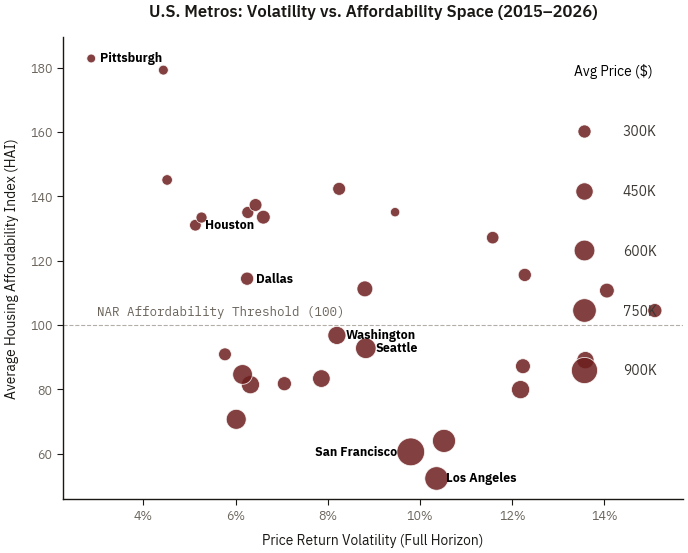

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_rankings, 
    x='Price Volatility (Full)', 
    y='Avg HAI', 
    size='Avg Price ($)', 
    sizes=(40, 400), 
    alpha=0.85, 
    color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'),
    ax=ax
)

# Add labels for key metros
highlight_metros = ['San Francisco, CA', 'Seattle, WA', 'Houston, TX', 'Washington, DC', 'Los Angeles, CA', 'Pittsburgh, PA', 'Dallas, TX']
for idx, row in df_rankings.iterrows():
    if row['Metro'] in highlight_metros:
        # San Francisco's label collides with Los Angeles on the right; place it to the left.
        left_label = row['Metro'].startswith('San Francisco')
        ax.text(
            row['Price Volatility (Full)'] + (-0.003 if left_label else 0.002), 
            row['Avg HAI'], 
            row['Metro'].split(',')[0], 
            fontsize=9, 
            fontfamily='IBM Plex Sans', 
            weight='bold',
            ha='right' if left_label else 'left',
            va='center'
        )

# Draw affordability threshold of 100
ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(0.03, 103, 'NAR Affordability Threshold (100)', fontsize=9, color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')

ax.set_title('U.S. Metros: Volatility vs. Affordability Space (2015–2026)', fontsize=12, pad=15)
ax.set_xlabel('Price Return Volatility (Full Horizon)', fontsize=10, labelpad=8)
ax.set_ylabel('Average Housing Affordability Index (HAI)', fontsize=10, labelpad=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))

# Fix legend: format size labels as K values
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for label in labels:
    try:
        val = float(label)
        new_labels.append(f"{val/1000:.0f}K")
    except ValueError:
        new_labels.append(label)
ax.legend(handles, new_labels, title='Avg Price ($)', frameon=False, loc='upper right',
          labelspacing=3.3, handletextpad=1.8, borderpad=1.4, title_fontsize=10)

# Save figure
fig.savefig(os.path.join(FIG_DIR, 'volatility_vs_affordability.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

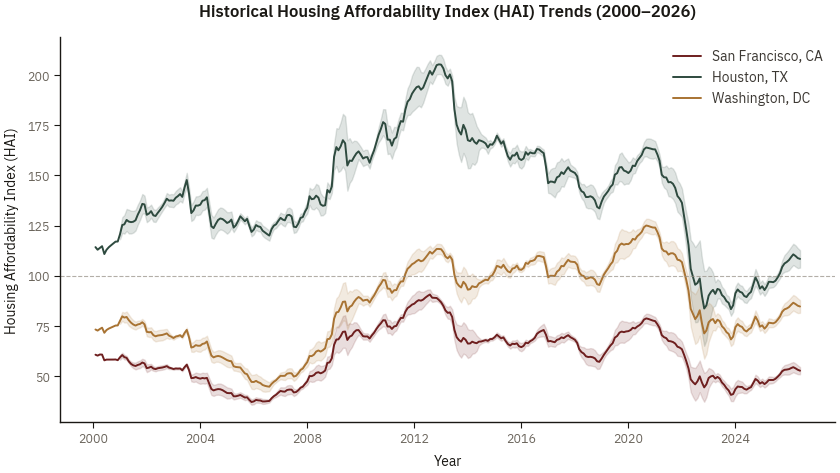

In [7]:
# Let's load the time series for three representative metros to plot over time
plot_metros = {
    'San Francisco, CA': 'oxblood',   # Archetype A
    'Houston, TX': 'forest',          # Archetype B
    'Washington, DC': 'ochre'          # Archetype C
}

fig, ax = plt.subplots(figsize=(10, 5))

for metro_name, color_name in plot_metros.items():
    # Recalculate monthly series
    row = df_zillow[df_zillow['RegionName'].str.startswith(metro_name, na=False)]
    home_vals = row[cols_date].iloc[0].values
    df_p = pd.DataFrame({'DATE': pd.to_datetime(cols_date), 'Price': home_vals})
    df_p['DATE'] = df_p['DATE'] + pd.offsets.MonthEnd(0)
    df_merged = pd.merge(df_p, df_mort, on='DATE')
    df_merged = pd.merge(df_merged, incomes_monthly[metro_name], on='DATE')
    
    df_merged['r'] = df_merged['MortgageRate'] / 100 / 12
    df_merged['MonthlyPI'] = (df_merged['Price'] * 0.80) * (df_merged['r'] * (1 + df_merged['r'])**360) / ((1 + df_merged['r'])**360 - 1)
    df_merged['HAI'] = (df_merged['Income'] / (df_merged['MonthlyPI'] * 48)) * 100

    # Plot the line
    ax.plot(df_merged['DATE'], df_merged['HAI'], label=metro_name, color=portfolio_style.COLORS.get(color_name))
    
    # Add uncertainty/variability bands (representing +/- 1 SD of HAI over the full history for that month)
    # For simplicity, we show a rolling 12-month standard deviation as a shaded uncertainty band around the trend
    rolling_sd = df_merged['HAI'].rolling(12).std()
    ax.fill_between(
        df_merged['DATE'], 
        df_merged['HAI'] - rolling_sd, 
        df_merged['HAI'] + rolling_sd, 
        color=portfolio_style.COLORS.get(color_name), 
        alpha=0.15
    )

ax.axhline(100, color=portfolio_style.COLORS.get('ink_4'), linestyle='--', linewidth=0.8, alpha=0.7)
ax.legend(frameon=False, loc='upper right')
ax.set_title('Historical Housing Affordability Index (HAI) Trends (2000–2026)', fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)

# Save figure
fig.savefig(os.path.join(FIG_DIR, 'hai_trends_over_time.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

## 6. Three archetypes, one shielding test

The ranking above and the scatter plot settle into three structural archetypes. I think the labels hold up, though the boundaries are inherently judgment calls.

**Archetype A — Expensive, volatile, and structurally unaffordable (coastal superstars).** San Francisco (avg HAI since 2015: 60.6, full-period volatility: 9.80%) and Seattle (avg HAI since 2015: 92.8, full-period volatility: 8.82%). These tech-driven coastal gateways sit well below or near the HAI = 100 qualification threshold for a median household, and their prices swing with interest-rate cycles and supply constraints. The combination of low affordability and high volatility is the signature of a market where timing and income both work against the median buyer.

**Archetype B — Affordable and stable (low-cost heartland/sunbelt).** Houston (avg HAI since 2015: 131.0, full-period volatility: 5.13%). Flexible supply and lower entry prices put the median household roughly a third above the qualification threshold, and price swings are half those of Archetype A. Which means: less upside in booms, but also less exposure to negative equity in downturns.

**Archetype C — The threshold case (balanced metro).** Washington, DC (avg HAI since 2015: 96.8, full-period volatility: 8.20%). This market tracks near the HAI = 100 line with moderate volatility — the archetype of a market where affordability is precarious but not yet structurally closed.

### Intra-metro income shielding: Fairfax County versus the District
To test how localized income dynamics alter the picture, I compare the Washington MSA price index matched against two very different incomes: the District of Columbia's median household income and the substantially higher income of the Fairfax County, VA commuter belt. By construction, this static comparison yields a higher HAI for the wealthier county since both calculations share the exact same price and interest rate series (making the higher affordability score arithmetically guaranteed by the higher income in the numerator). The real empirical finding, however, is not this static gap but rather the temporal convergence of their ratio, which is explored in detail in the Archetype C dynamics notebook.


In [8]:
# Load Fairfax County income data
df_ffx = load_clean_fred_series(os.path.join(DATA_DIR, 'MHI_Fairfax_County_VA.csv'))
df_ffx['DATE'] = df_ffx['DATE'] + pd.offsets.YearEnd()

# Project Fairfax income for 2025/2026
ffx_val_3yr = df_ffx.iloc[-4]['value']
ffx_growth = (df_ffx.iloc[-1]['value'] / ffx_val_3yr) ** (1/3) - 1
proj_ffx = []
curr_date = df_ffx.iloc[-1]['DATE']
curr_val = df_ffx.iloc[-1]['value']
while curr_date.year < 2026:
    curr_date = curr_date + pd.offsets.DateOffset(years=1)
    curr_val = curr_val * (1 + ffx_growth)
    proj_ffx.append({'DATE': curr_date, 'value': curr_val})
if proj_ffx:
    df_ffx = pd.concat([df_ffx, pd.DataFrame(proj_ffx)], ignore_index=True)

# Monthly interpolation for Fairfax County
all_months_ffx = pd.date_range(start=df_ffx['DATE'].min(), end=df_ffx['DATE'].max(), freq='ME')
df_ffx_m = pd.DataFrame(index=all_months_ffx)
df_ffx_m = df_ffx_m.join(df_ffx.set_index('DATE')[['value']], how='left')
df_ffx_m['value'] = df_ffx_m['value'].interpolate(method='linear')
df_ffx_m = df_ffx_m.reset_index().rename(columns={'index': 'DATE', 'value': 'Fairfax_Income'})

# Extract Washington DC MSA prices
wash_row = df_zillow[df_zillow['RegionName'].str.startswith('Washington, DC', na=False)]
df_wash_p = pd.DataFrame({'DATE': pd.to_datetime(cols_date), 'Price': wash_row[cols_date].iloc[0].values})
df_wash_p['DATE'] = df_wash_p['DATE'] + pd.offsets.MonthEnd(0)

# Merge price, mortgage, Fairfax income, and District of Columbia income
df_ffx_merged = pd.merge(df_wash_p, df_mort, on='DATE')
df_ffx_merged = pd.merge(df_ffx_merged, df_ffx_m, on='DATE')
df_ffx_merged = pd.merge(df_ffx_merged, incomes_monthly['Washington, DC'], on='DATE')

# Calculate HAIs
df_ffx_merged['r'] = df_ffx_merged['MortgageRate'] / 100 / 12
df_ffx_merged['MonthlyPI'] = (df_ffx_merged['Price'] * 0.80) * (df_ffx_merged['r'] * (1 + df_ffx_merged['r'])**360) / ((1 + df_ffx_merged['r'])**360 - 1)
df_ffx_merged['HAI_DC_Core'] = (df_ffx_merged['Income'] / (df_ffx_merged['MonthlyPI'] * 48)) * 100
df_ffx_merged['HAI_Fairfax'] = (df_ffx_merged['Fairfax_Income'] / (df_ffx_merged['MonthlyPI'] * 48)) * 100

# Compute averages since 2015
df_ffx_recent = df_ffx_merged[df_ffx_merged['DATE'] >= '2015-01-01']
print("--- INTRA-METRO AFFORDABILITY DISPARITY (WASHINGTON MSA) ---")
print(f"Washington MSA Typical Price:               ${df_ffx_recent['Price'].mean():,.2f}")
print(f"District of Columbia Core Median Income:    ${df_ffx_recent['Income'].mean():,.2f}")
print(f"Fairfax County, VA Suburban Median Income:   ${df_ffx_recent['Fairfax_Income'].mean():,.2f}")
print(f"\nAverage HAI (DC Core Income):               {df_ffx_recent['HAI_DC_Core'].mean():.2f}")
print(f"Average HAI (Fairfax County Income):          {df_ffx_recent['HAI_Fairfax'].mean():.2f}")
print(f"\nLatest HAI Jan 2026 (DC Core Income):        {df_ffx_merged['HAI_DC_Core'].iloc[-1]:.2f}")
print(f"Latest HAI Jan 2026 (Fairfax County Income): {df_ffx_merged['HAI_Fairfax'].iloc[-1]:.2f}")

--- INTRA-METRO AFFORDABILITY DISPARITY (WASHINGTON MSA) ---
Washington MSA Typical Price:               $481,757.80
District of Columbia Core Median Income:    $91,207.32
Fairfax County, VA Suburban Median Income:   $132,127.86

Average HAI (DC Core Income):               96.79
Average HAI (Fairfax County Income):          141.51

Latest HAI Jan 2026 (DC Core Income):        84.72
Latest HAI Jan 2026 (Fairfax County Income): 116.89


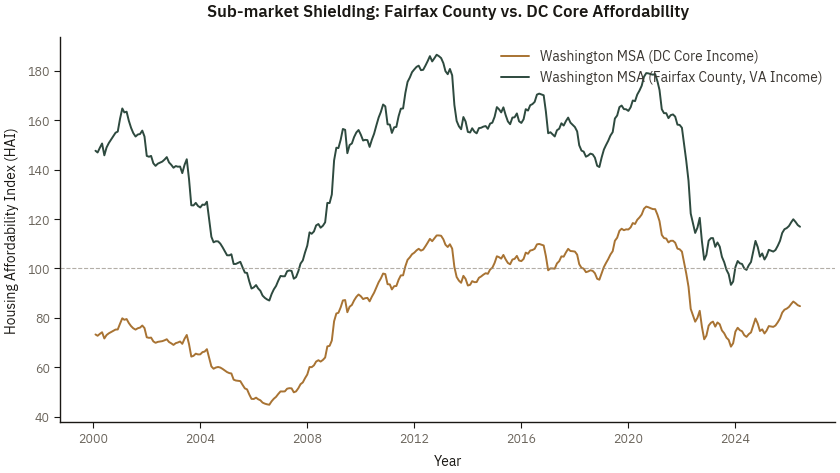

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_ffx_merged['DATE'], df_ffx_merged['HAI_DC_Core'], label='Washington MSA (DC Core Income)', color=portfolio_style.COLORS.get('ochre'))
ax.plot(df_ffx_merged['DATE'], df_ffx_merged['HAI_Fairfax'], label='Washington MSA (Fairfax County, VA Income)', color=portfolio_style.COLORS.get('forest'))
ax.axhline(100, color=portfolio_style.COLORS.get('ink_4'), linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Sub-market Shielding: Fairfax County vs. DC Core Affordability', fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper right')

fig.savefig(os.path.join(FIG_DIR, 'fairfax_vs_dc_shielding.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

## 7. Where I would not follow this data

Three boundaries worth stating plainly:

1. **No individual credit verification.** The HAI is a median-household-against-typical-home metric. It says nothing about a specific buyer's debt burden, credit score, or liquid savings. A household can live in a market with HAI well above 100 and still find homeownership inaccessible.
2. **No forward-looking regime prediction.** Everything here is backward-looking (2000–2026). These volatility and return measures do not predict future mortgage-rate shocks, regional employment collapses, or sudden supply-wave deregulations. I suspect historical volatility is a reasonable prior for near-term risk, but I would not stake a ten-year plan on it without updating annually.
3. **No non-mortgage carrying costs.** The NAR HAI isolates principal and interest. It omits property taxes, insurance, maintenance, utilities, and HOA fees. In states with high property-tax rates (Texas) or high insurance rates (Florida), the actual monthly carrying cost runs meaningfully above the mortgage-only figure. Houston's affordability edge over Washington, for instance, narrows once Texas property taxes enter the picture — a caveat that belongs in any honest comparison of those two metros, and one that a follow-up notebook could quantify by layering county-level effective tax rates onto the HAI formula.


In [10]:
# Regenerate metro_rankings.csv from in-vivo data to keep the artifact traceable
df_to_csv = df_rankings.rename(columns={
    'Avg Price ($)': 'Avg_Price',
    'Avg HAI': 'Avg_HAI',
    'Price Volatility (Recent)': 'Recent_Vol',
    'Price Volatility (Full)': 'Full_Vol',
    'Avg YoY Return': 'Avg_YoY_Return',
    'Latest Price ($)': 'Latest_Price',
    'Latest HAI': 'Latest_HAI'
})
# Ensure exact column order as original file
df_to_csv = df_to_csv[['Metro', 'Avg_Price', 'Avg_HAI', 'Recent_Vol', 'Full_Vol', 'Avg_YoY_Return', 'Latest_Price', 'Latest_HAI']]
df_to_csv.to_csv('../data/real/metro_rankings.csv', index=False)
print("✓ metro_rankings.csv successfully updated from in-vivo data in original column order.")

✓ metro_rankings.csv successfully updated from in-vivo data in original column order.
